In [25]:
import gymnasium as gym


from gym.wrappers import RecordVideo

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import csv
import time

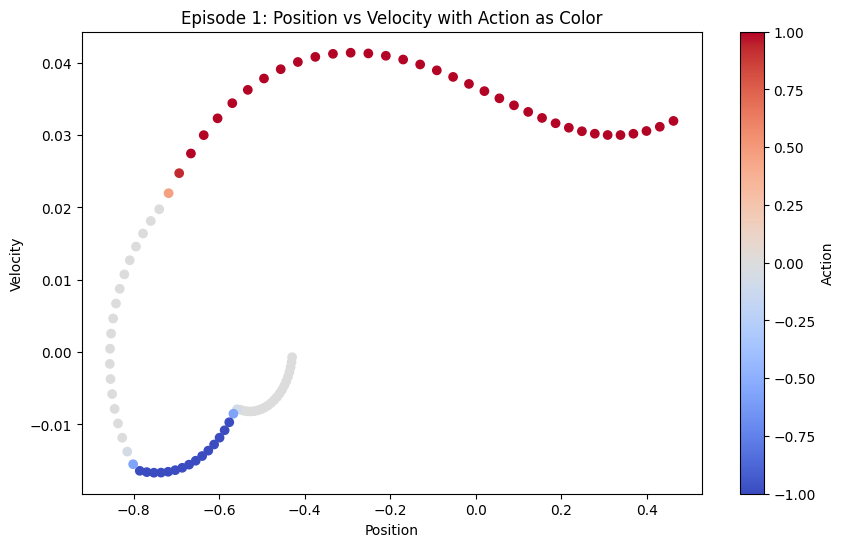

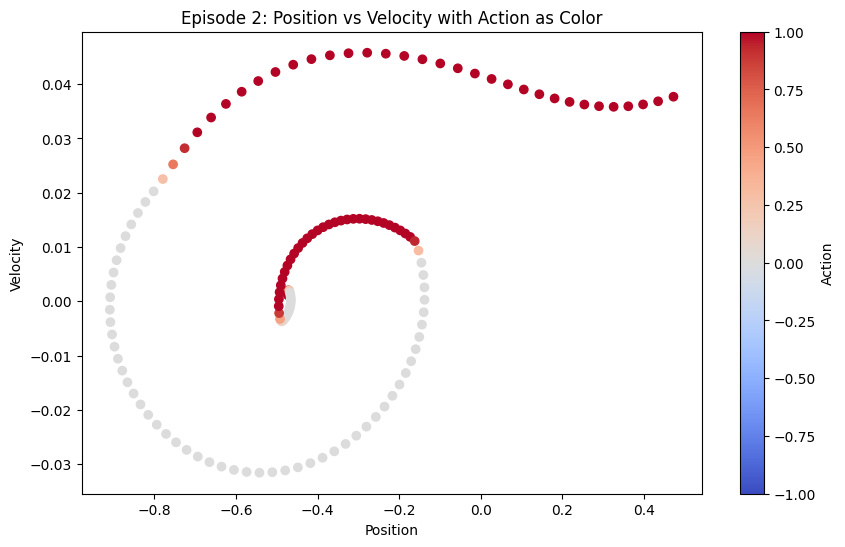

In [2]:
# 读取CSV并按 episode 组织数据
def load_csv_data_by_episode(csv_file):
    episodes_dict = {}
    
    with open(csv_file, newline='') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            episode = int(row['episode'])
            
            if episode not in episodes_dict:
                episodes_dict[episode] = []
            
            # 将每一行的数据保存到相应的 episode 中
            episodes_dict[episode].append({
                'step': int(row['step']),
                'position': float(row['position']),
                'velocity': float(row['velocity']),
                'action': float(row['action'])
            })
    
    return episodes_dict

# 绘制每个 episode 的 position, velocity, action 作为颜色的散点图
def plot_episode(episode_data, episode_number):
    positions = [step_data['position'] for step_data in episode_data]
    velocities = [step_data['velocity'] for step_data in episode_data]
    actions = [step_data['action'] for step_data in episode_data]
    
    plt.figure(figsize=(10, 6))

    # 绘制 position 和 velocity 的散点图，颜色根据 action 来映射
    scatter = plt.scatter(positions, velocities, c=actions, cmap='coolwarm', vmin=-1, vmax=1)

    # 添加颜色条，用于显示 action 的数值范围
    cbar = plt.colorbar(scatter)
    cbar.set_label('Action')

    # 添加标题和轴标签
    plt.title(f'Episode {episode_number}: Position vs Velocity with Action as Color')
    plt.xlabel('Position')
    plt.ylabel('Velocity')
    

    # 显示图表
    plt.show()

# 主函数：读取 CSV 文件并绘制所有 episode
def plot_all_episodes(csv_file):
    episodes_dict = load_csv_data_by_episode(csv_file)
    
    # 对每个 episode 绘制图像
    for episode_number, episode_data in episodes_dict.items():
        plot_episode(episode_data, episode_number)

# 示例调用
csv_filepath = './data/manual_policy.csv'  # 替换为你的 CSV 文件路径
plot_all_episodes(csv_filepath)

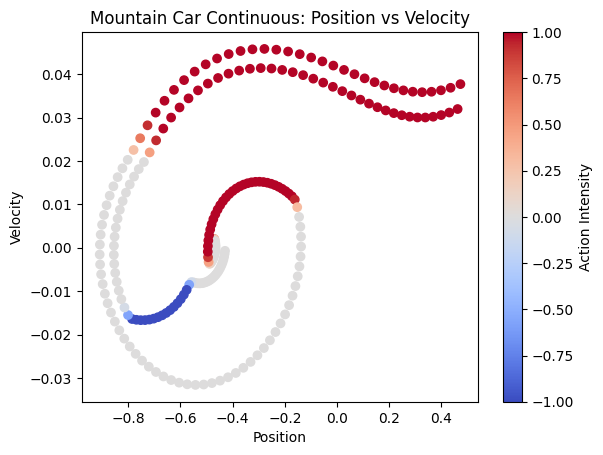

In [3]:
# 读取CSV并按 episode 组织数据
def load_csv_data_by_episode(csv_file):
    episodes_dict = {}
    
    with open(csv_file, newline='') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            episode = int(row['episode'])
            
            if episode not in episodes_dict:
                episodes_dict[episode] = []
            
            # 将每一行的数据保存到相应的 episode 中
            episodes_dict[episode].append({
                'step': int(row['step']),
                'position': float(row['position']),
                'velocity': float(row['velocity']),
                'action': float(row['action'])
            })
    
    return episodes_dict

# 绘制单个 episode 的散点图
def plot_episode_scatter(episode_data, ax):
    positions = [data['position'] for data in episode_data]
    velocities = [data['velocity'] for data in episode_data]
    actions = [data['action'] for data in episode_data]

    # 使用 actions 作为颜色
    scatter = ax.scatter(positions, velocities, c=actions, cmap='coolwarm', vmin=-1, vmax=1, label='Episode')
    
    return scatter

# 绘制所有 episode 的叠加散点图
def plot_all_episodes_scatter(episodes_dict):
    fig, ax = plt.subplots()

    # 遍历所有 episodes 并绘制散点图
    for episode, episode_data in episodes_dict.items():
        plot_episode_scatter(episode_data, ax)

    # 添加颜色条表示 action 的强度
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label('Action Intensity')

    # 设置图表标题和轴标签
    ax.set_title('Mountain Car Continuous: Position vs Velocity')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')

    # 显示图表
    plt.show()

if __name__ == '__main__':
    # 加载CSV数据
    csv_file = './data/manual_policy.csv'  # 替换为你的CSV文件路径
    episodes_dict = load_csv_data_by_episode(csv_file)

    # 绘制所有 episodes 的叠加散点图
    plot_all_episodes_scatter(episodes_dict)

### Combined function : plot each episode and save, add them together and save

In [26]:
# 读取CSV并按 episode 组织数据
def load_csv_data_by_episode(csv_file):
    episodes_dict = {}
    
    with open(csv_file, newline='') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            episode = int(row['episode'])
            
            if episode not in episodes_dict:
                episodes_dict[episode] = []
            
            # 将每一行的数据保存到相应的 episode 中
            episodes_dict[episode].append({
                'step': int(row['step']),
                'position': float(row['position']),
                'velocity': float(row['velocity']),
                'action': float(row['action'])
            })
    
    return episodes_dict

# 绘制单个 episode 的散点图
def plot_episode_scatter(episode_data, ax, s=10): 
    positions = [data['position'] for data in episode_data]
    velocities = [data['velocity'] for data in episode_data]
    actions = [data['action'] for data in episode_data]

    # 使用 actions 作为颜色
    scatter = ax.scatter(positions, velocities, c=actions, cmap='coolwarm', vmin=-1, vmax=1, s=s)  # 设置散点大小
    
    return scatter

# 绘制并保存每个 episode 的散点图
def plot_and_save_individual_episodes(episodes_dict, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for episode, episode_data in episodes_dict.items():
        fig, ax = plt.subplots()
        
        # 绘制单个 episode 的散点图
        scatter = plot_episode_scatter(episode_data, ax,s=15)
        
        # 添加颜色条表示 action 的强度
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Action Intensity')
        
        # 设置图表标题和轴标签
        ax.set_title(f'Episode {episode}: Position vs Velocity')
        ax.set_xlabel('Position')
        ax.set_ylabel('Velocity')

        # 保存每个 episode 的散点图
        save_path = os.path.join(output_dir, f'episode_{episode}.png')
        plt.savefig(save_path, format='png', dpi=300)
        print(f"Episode {episode} scatter plot saved to {save_path}")

        plt.close(fig)  # 关闭当前图以释放内存

# 绘制所有 episode 的叠加散点图并保存
def plot_and_save_all_episodes(episodes_dict, save_path):
    fig, ax = plt.subplots()

    # 遍历所有 episodes 并绘制散点图
    for episode, episode_data in episodes_dict.items():
        plot_episode_scatter(episode_data, ax, s=2)

    # 添加颜色条表示 action 的强度
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label('Action Intensity')

    # 设置图表标题和轴标签
    ax.set_title('All Episodes: Position vs Velocity')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')

    # 保存所有 episode 的叠加散点图
    plt.savefig(save_path, format='png', dpi=300)
    print(f"All episodes scatter plot saved to {save_path}")
    
    plt.close(fig)  # 关闭当前图以释放内存

# if __name__ == '__main__':
#     # 加载CSV数据
#     csv_file = './data/manual_policy_100_LR_RLR.csv'  # 替换为你的CSV文件路径
#     episodes_dict = load_csv_data_by_episode(csv_file)

#     # 定义保存路径
#     output_dir = 'episode_plots'  # 保存单个 episode 的图片目录
#     all_episodes_save_path = f"{os.path.splitext(csv_file)[0]}_all_episodes.png"  # 保存所有叠加散点图的路径

#     # 绘制并保存每个 episode 的散点图
#     plot_and_save_individual_episodes(episodes_dict, output_dir)
    
#     # 绘制并保存所有 episodes 叠加的散点图
#     plot_and_save_all_episodes(episodes_dict, all_episodes_save_path)



single csv

In [ ]:
if __name__ == '__main__':
    # 加载CSV数据
    csv_file = './data/manual_policy_100_LR.csv'  # 替换为你的CSV文件路径
    episodes_dict = load_csv_data_by_episode(csv_file)

    # 从CSV文件路径中提取文件名（不含扩展名）
    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    # 定义保存路径
    output_dir = os.path.join(os.path.dirname(csv_file), base_name)  # 保存单个 episode 的图片目录
    all_episodes_save_path = os.path.join(output_dir, f"{base_name}_all_episodes.png")  # 保存所有叠加散点图的路径

    # 如果输出目录不存在，则创建它
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 绘制并保存每个 episode 的散点图
    plot_and_save_individual_episodes(episodes_dict, output_dir)
    
    # 绘制并保存所有 episodes 叠加的散点图
    plot_and_save_all_episodes(episodes_dict, all_episodes_save_path)

all csv in the folder

In [28]:
# 主函数：对文件夹中的所有CSV文件进行处理
if __name__ == '__main__':
    data_folder = './data2'  # 你想处理的文件夹路径

    # 遍历文件夹中的所有CSV文件
    for filename in os.listdir(data_folder):
        if filename.endswith('.csv'):
            csv_file = os.path.join(data_folder, filename)
            episodes_dict = load_csv_data_by_episode(csv_file)

            # 从CSV文件路径中提取文件名（不含扩展名）
            base_name = os.path.splitext(os.path.basename(csv_file))[0]
            # 定义保存路径
            output_dir = os.path.join(data_folder, base_name)  # 保存单个 episode 的图片目录
            all_episodes_save_path = os.path.join(output_dir, f"{base_name}_all_episodes.png")  # 保存所有叠加散点图的路径

            # 如果输出目录不存在，则创建它
            if not os.path.exists(output_dir):
                os.makedirs(output_dir)

            # 绘制并保存每个 episode 的散点图
            plot_and_save_individual_episodes(episodes_dict, output_dir)

            # 绘制并保存所有 episodes 叠加的散点图
            plot_and_save_all_episodes(episodes_dict, all_episodes_save_path)

Episode 1 scatter plot saved to ./data2\fixed_policy_data_10\episode_1.png
Episode 2 scatter plot saved to ./data2\fixed_policy_data_10\episode_2.png
Episode 3 scatter plot saved to ./data2\fixed_policy_data_10\episode_3.png
Episode 4 scatter plot saved to ./data2\fixed_policy_data_10\episode_4.png
Episode 5 scatter plot saved to ./data2\fixed_policy_data_10\episode_5.png
Episode 6 scatter plot saved to ./data2\fixed_policy_data_10\episode_6.png
Episode 7 scatter plot saved to ./data2\fixed_policy_data_10\episode_7.png
Episode 8 scatter plot saved to ./data2\fixed_policy_data_10\episode_8.png
Episode 9 scatter plot saved to ./data2\fixed_policy_data_10\episode_9.png
Episode 10 scatter plot saved to ./data2\fixed_policy_data_10\episode_10.png
All episodes scatter plot saved to ./data2\fixed_policy_data_10\fixed_policy_data_10_all_episodes.png
Episode 1 scatter plot saved to ./data2\fixed_policy_data_100\episode_1.png
Episode 2 scatter plot saved to ./data2\fixed_policy_data_100\episode_